In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df1 = pd.read_csv('../data/query_01.csv')
df2 = pd.read_csv('../data/query_02.csv')

## 2. Inspeção inicial e qualidade dos dados

In [4]:
# Análise exploratória dos dados

for nome, df in {
    "Query 1": df1,
    "Query 2": df2
}.items():
    print(f"\n{nome}")
    print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
    display(df.head())
    df.info()


Query 1
Linhas: 107 | Colunas: 10


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,HIRE_DATE,SALARY,DEPARTMENT_ID,DEPARTMENT_NAME,JOB_TITLE,MIN_SALARY,MAX_SALARY
0,205,Shelley,Higgins,2012-06-07T00:00:00Z,12008,110.0,Accounting,Accounting Manager,8200,16000
1,206,William,Gietz,2012-06-07T00:00:00Z,8300,110.0,Accounting,Public Accountant,4200,9000
2,200,Jennifer,Whalen,2013-09-17T00:00:00Z,4400,10.0,Administration,Administration Assistant,3000,6000
3,102,Lex,Garcia,2011-01-13T00:00:00Z,17000,90.0,Executive,Administration Vice President,15000,30000
4,101,Neena,Yang,2015-09-21T00:00:00Z,17000,90.0,Executive,Administration Vice President,15000,30000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   EMPLOYEE_ID      107 non-null    int64  
 1   FIRST_NAME       107 non-null    object 
 2   LAST_NAME        107 non-null    object 
 3   HIRE_DATE        107 non-null    object 
 4   SALARY           107 non-null    int64  
 5   DEPARTMENT_ID    106 non-null    float64
 6   DEPARTMENT_NAME  106 non-null    object 
 7   JOB_TITLE        107 non-null    object 
 8   MIN_SALARY       107 non-null    int64  
 9   MAX_SALARY       107 non-null    int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 8.5+ KB

Query 2
Linhas: 107 | Colunas: 14


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,HIRE_DATE,SALARY,DEPARTMENT_ID,DEPARTMENT_NAME,LOCATION_ID,CITY,STATE_PROVINCE,COUNTRY_ID,COUNTRY_NAME,REGION_ID,REGION_NAME
0,201,Michael,Martinez,2014-02-17T00:00:00Z,13000,20.0,Marketing,1800.0,Toronto,Ontario,CA,Canada,20.0,Americas
1,202,Pat,Davis,2015-08-17T00:00:00Z,6000,20.0,Marketing,1800.0,Toronto,Ontario,CA,Canada,20.0,Americas
2,100,Steven,King,2013-06-17T00:00:00Z,24000,90.0,Executive,1700.0,Seattle,Washington,US,United States of America,20.0,Americas
3,101,Neena,Yang,2015-09-21T00:00:00Z,17000,90.0,Executive,1700.0,Seattle,Washington,US,United States of America,20.0,Americas
4,102,Lex,Garcia,2011-01-13T00:00:00Z,17000,90.0,Executive,1700.0,Seattle,Washington,US,United States of America,20.0,Americas


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   EMPLOYEE_ID      107 non-null    int64  
 1   FIRST_NAME       107 non-null    object 
 2   LAST_NAME        107 non-null    object 
 3   HIRE_DATE        107 non-null    object 
 4   SALARY           107 non-null    int64  
 5   DEPARTMENT_ID    106 non-null    float64
 6   DEPARTMENT_NAME  106 non-null    object 
 7   LOCATION_ID      106 non-null    float64
 8   CITY             106 non-null    object 
 9   STATE_PROVINCE   105 non-null    object 
 10  COUNTRY_ID       106 non-null    object 
 11  COUNTRY_NAME     106 non-null    object 
 12  REGION_ID        106 non-null    float64
 13  REGION_NAME      106 non-null    object 
dtypes: float64(3), int64(2), object(9)
memory usage: 11.8+ KB


In [5]:
# Verificando valores ausentes e duplicados

for nome, df in {
    "Query 1": df1,
    "Query 2": df2
}.items():
    print(f"\n{nome}")
    display(df.isna().sum().rename("Valores ausentes"))
    print("Linhas duplicadas:", df.duplicated().sum())
  


Query 1


EMPLOYEE_ID        0
FIRST_NAME         0
LAST_NAME          0
HIRE_DATE          0
SALARY             0
DEPARTMENT_ID      1
DEPARTMENT_NAME    1
JOB_TITLE          0
MIN_SALARY         0
MAX_SALARY         0
Name: Valores ausentes, dtype: int64

Linhas duplicadas: 0

Query 2


EMPLOYEE_ID        0
FIRST_NAME         0
LAST_NAME          0
HIRE_DATE          0
SALARY             0
DEPARTMENT_ID      1
DEPARTMENT_NAME    1
LOCATION_ID        1
CITY               1
STATE_PROVINCE     2
COUNTRY_ID         1
COUNTRY_NAME       1
REGION_ID          1
REGION_NAME        1
Name: Valores ausentes, dtype: int64

Linhas duplicadas: 0


In [6]:
# Conversão de tipos de dados

for df in [df1, df2]:
    df['HIRE_DATE'] = pd.to_datetime(df['HIRE_DATE'], errors='coerce')
    
for coluna in ["EMPLOYEE_ID", "DEPARTMENT_ID"]:
    df1[coluna] = pd.to_numeric(
        df1[coluna],
        errors="coerce"
    ).astype("Int64")
    
for coluna in [
    "EMPLOYEE_ID",
    "DEPARTMENT_ID",
    "LOCATION_ID",
    "REGION_ID"
]:
    df2[coluna] = pd.to_numeric(
        df2[coluna],
        errors="coerce"
    ).astype("Int64")


df1.info()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   EMPLOYEE_ID      107 non-null    Int64              
 1   FIRST_NAME       107 non-null    object             
 2   LAST_NAME        107 non-null    object             
 3   HIRE_DATE        107 non-null    datetime64[ns, UTC]
 4   SALARY           107 non-null    int64              
 5   DEPARTMENT_ID    106 non-null    Int64              
 6   DEPARTMENT_NAME  106 non-null    object             
 7   JOB_TITLE        107 non-null    object             
 8   MIN_SALARY       107 non-null    int64              
 9   MAX_SALARY       107 non-null    int64              
dtypes: Int64(2), datetime64[ns, UTC](1), int64(3), object(4)
memory usage: 8.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 14 columns):
 #   Colum

## 3. Estatísticas descritivas

Nesta etapa serão analisadas as principais medidas estatísticas dos salários dos funcionários, bem como a distribuição por departamentos, cargos e localização geográfica.

In [ ]:
# Estatísticas descritivas da coluna de salários - Query 1

df1["SALARY"].describe()


count      107.000000
mean      6461.831776
std       3909.579731
min       2100.000000
25%       3100.000000
50%       6200.000000
75%       8900.000000
max      24000.000000
Name: SALARY, dtype: float64

In [9]:
# Estatísticas descritivas da coluna de salários - Query 2

df2["SALARY"].describe()

count      107.000000
mean      6461.831776
std       3909.579731
min       2100.000000
25%       3100.000000
50%       6200.000000
75%       8900.000000
max      24000.000000
Name: SALARY, dtype: float64

In [12]:
# Resumo estatístico dos salários
resumo_salarios = pd.DataFrame({
    "Média": [df1["SALARY"].mean()],
    "Mediana": [df1["SALARY"].median()],
    "Menor salário": [df1["SALARY"].min()],
    "Maior salário": [df1["SALARY"].max()],
    "Desvio padrão": [df1["SALARY"].std()]
})

print("\nResumo estatístico dos salários (Query 1):")
resumo_salarios.round(2)


Resumo estatístico dos salários (Query 1):


,Média,Mediana,Menor salário,Maior salário,Desvio padrão
0,6461.83,6200.0,2100,24000,3909.58


In [14]:
# Salário médio por departamento
salario_por_departamento = (
    df1
    .groupby("DEPARTMENT_NAME")["SALARY"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
    .round(2)
)

salario_por_departamento

,count,mean,median,min,max
DEPARTMENT_NAME,,,,,
Executive,3,19333.33,17000.0,17000,24000
Accounting,2,10154.00,10154.0,8300,12008
Public Relations,1,10000.00,10000.0,10000,10000
Marketing,2,9500.00,9500.0,6000,13000
Sales,34,8955.88,8900.0,6100,14000
Finance,6,8601.33,8000.0,6900,12008
Human Resources,1,6500.00,6500.0,6500,6500
IT,5,5760.00,4800.0,4200,9000
Administration,1,4400.00,4400.0,4400,4400


### 3.1 Análise salarial por cargo

Nesta etapa será analisada a distribuição dos salários de acordo com os cargos ocupados pelos funcionários.

In [15]:
# Salário por cargo
salario_por_cargo = (
    df1
    .groupby("JOB_TITLE")["SALARY"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

salario_por_cargo.round(2)

,count,mean,median,min,max
JOB_TITLE,,,,,
President,1,24000.0,24000.0,24000,24000
Administration Vice President,2,17000.0,17000.0,17000,17000
Marketing Manager,1,13000.0,13000.0,13000,13000
Sales Manager,5,12200.0,12000.0,10500,14000
Finance Manager,1,12008.0,12008.0,12008,12008
Accounting Manager,1,12008.0,12008.0,12008,12008
Purchasing Manager,1,11000.0,11000.0,11000,11000
Public Relations Representative,1,10000.0,10000.0,10000,10000
Sales Representative,30,8350.0,8200.0,6100,11500


A análise por cargo permite observar diferenças salariais entre as funções da empresa. Cargos com maior média salarial tendem a estar associados a posições de maior responsabilidade, enquanto cargos com menor média representam funções operacionais ou de entrada.

Também é importante observar a coluna `count`, pois cargos com poucos funcionários podem apresentar médias menos representativas.

### 3.2 Análise salarial por localização geográfica

Nesta etapa será analisada a distribuição dos salários considerando a localização dos funcionários, incluindo região, país e cidade.

In [16]:
# Salário por região
salario_por_regiao = (
    df2
    .groupby("REGION_NAME")["SALARY"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
    .round(2)
)

salario_por_regiao

,count,mean,median,min,max
REGION_NAME,,,,,
Europe,36,8916.67,8900.0,6100,14000
Americas,70,5191.66,3300.0,2100,24000


In [17]:
# Salário por país
salario_por_pais = (
    df2
    .groupby("COUNTRY_NAME")["SALARY"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
    .round(2)
)

salario_por_pais

,count,mean,median,min,max
COUNTRY_NAME,,,,,
Germany,1,10000.00,10000.0,10000,10000
Canada,2,9500.00,9500.0,6000,13000
United Kingdom of Great Britain and Northern Ireland,35,8885.71,8800.0,6100,14000
United States of America,68,5064.94,3250.0,2100,24000


In [18]:
# Salário por cidade
salario_por_cidade = (
    df2
    .groupby("CITY")["SALARY"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
    .round(2)
)

salario_por_cidade

,count,mean,median,min,max
CITY,,,,,
Munich,1,10000.00,10000.0,10000,10000
Toronto,2,9500.00,9500.0,6000,13000
Oxford,34,8955.88,8900.0,6100,14000
Seattle,18,8845.33,8000.0,2500,24000
London,1,6500.00,6500.0,6500,6500
Southlake,5,5760.00,4800.0,4200,9000
South San Francisco,45,3475.56,3100.0,2100,8200


A análise geográfica permite identificar como os salários estão distribuídos entre regiões, países e cidades. Essa visão ajuda a compreender se determinadas localidades concentram funcionários com salários mais altos ou mais baixos.

Assim como na análise por cargo, é importante considerar a quantidade de funcionários em cada grupo, pois médias calculadas com poucos registros podem não representar uma tendência geral.

## 4. Visualização dos dados

Nesta etapa serão criados gráficos para apoiar a interpretação da distribuição salarial dos funcionários por departamentos, cargos e localização geográfica.

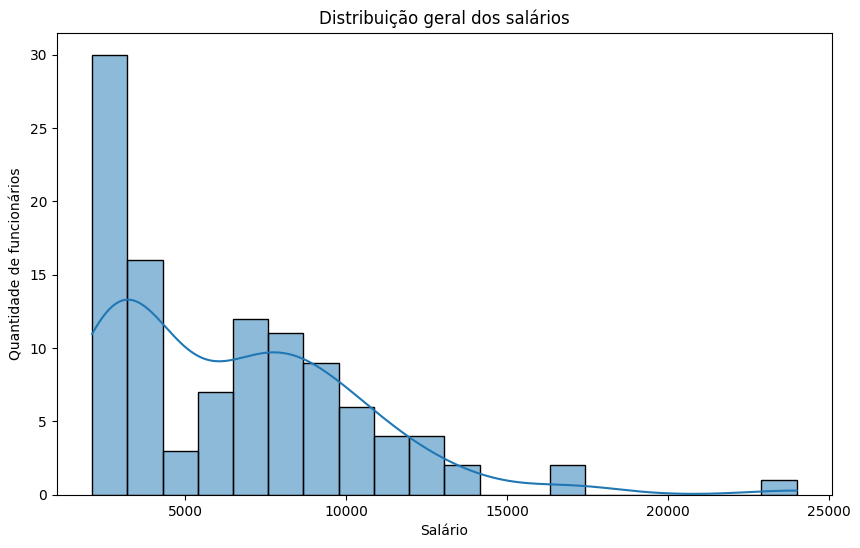

In [19]:
# Distribuição geral dos salários
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df1,
    x="SALARY",
    bins=20,
    kde=True
)

plt.title("Distribuição geral dos salários")
plt.xlabel("Salário")
plt.ylabel("Quantidade de funcionários")
plt.show()

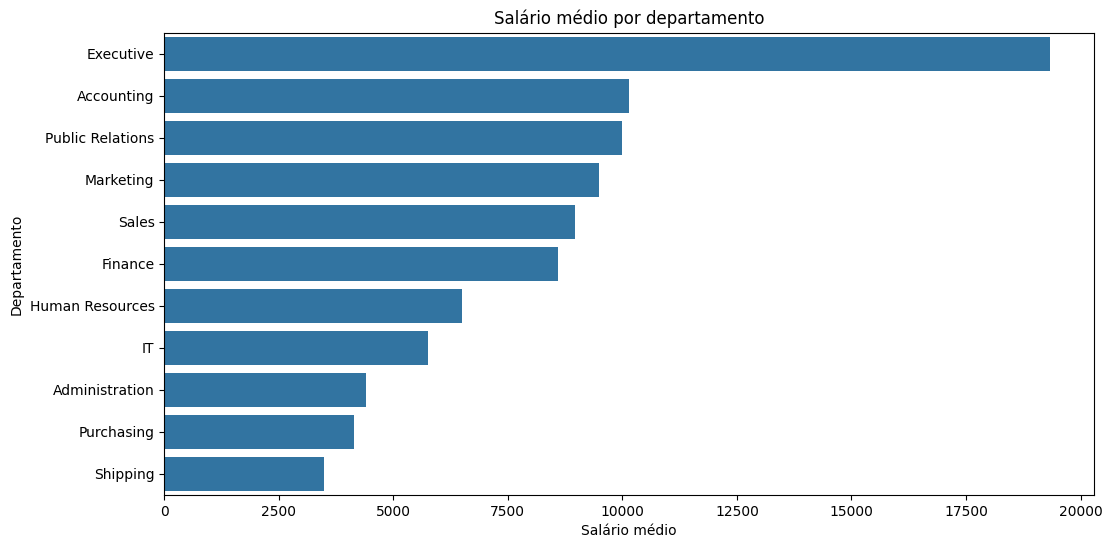

In [20]:
# Salário médio por departamento
salario_medio_departamento = (
    df1
    .groupby("DEPARTMENT_NAME")["SALARY"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=salario_medio_departamento.values,
    y=salario_medio_departamento.index
)

plt.title("Salário médio por departamento")
plt.xlabel("Salário médio")
plt.ylabel("Departamento")
plt.show()

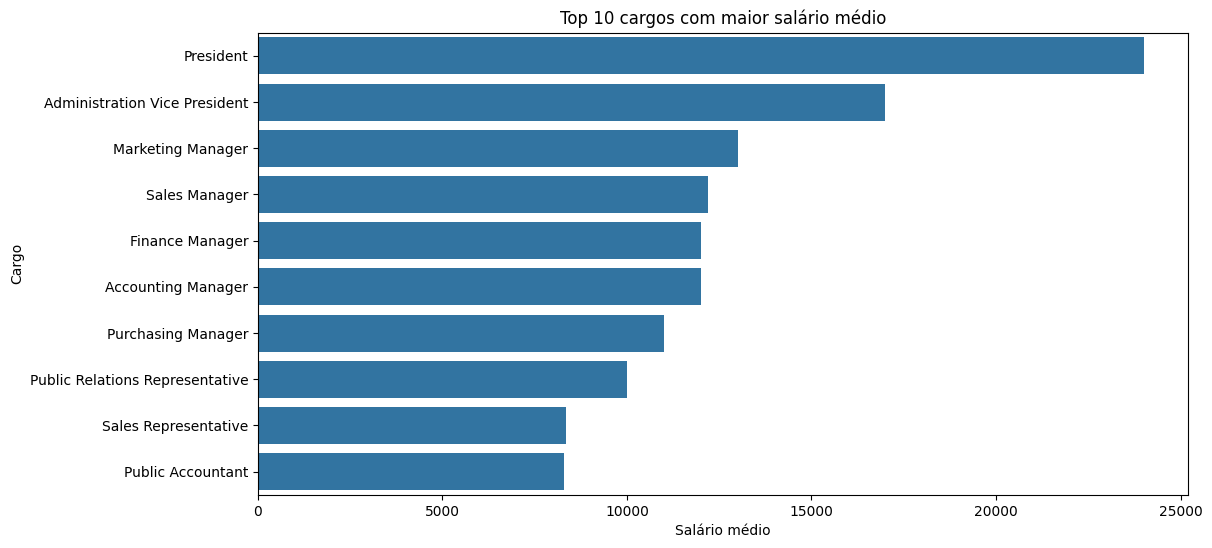

In [21]:
# Top 10 cargos com maior salário médio
top_10_cargos = (
    df1
    .groupby("JOB_TITLE")["SALARY"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_cargos.values,
    y=top_10_cargos.index
)

plt.title("Top 10 cargos com maior salário médio")
plt.xlabel("Salário médio")
plt.ylabel("Cargo")
plt.show()

Os gráficos permitem observar visualmente a concentração dos salários e comparar médias entre diferentes categorias. A distribuição geral dos salários ajuda a identificar concentração em determinadas faixas, enquanto os gráficos por departamento e cargo facilitam a identificação dos grupos com maiores médias salariais.